# Fig 2 — Cosmo (isotropic) null test

This figure tests whether non-Gaussianity in an **isotropic** background is detectable. We inject isotropic signals by drawing an independent complex amplitude at every sky pixel and polarization from three distributions — uniform, exponential, and normal — with **no discrete sources**, propagate them through the PTA response to the $N_p$ pulsars, whiten, and run the KS test on the whitened diagonal powers $|w_I|^2$. We report the fraction of realizations with $p<0.05$ as a function of $N_p$ (from 10 to 500).

The three panels compare whitening with the response $R_{IJ}$ versus the HD curve $\Gamma_{IJ}$, and the known-scale versus scale-estimated (bootstrap-calibrated) KS test. Regardless of the injected amplitude distribution the rejection fraction stays at the nominal $5\%$ in the bootstrapped test: an isotropic background is indistinguishable from the Gaussian null at the timing-residual level, and here whitening with $R$ or with the HD curve makes no difference.

## How to use this notebook
If you have downloaded this notebook from the repo set `REGENERATE_DATA = True` to recompute the data. It will be saved as `data/fig2_cosmo_KS_HDandR.npz`.

If you want to save the plot (it is saved under `plots/fig2_cosmo_KS_HDandR.pdf`), set `SAVE_PLOT` to True.

In [ ]:
REGENERATE_DATA = False
SAVE_PLOT       = True

In [ ]:
from pathlib import Path

import tqdm
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)

from helpers.pta_helpers import (
    set_paper_rcparams,
    setup_pta,
    naive_ks_pvalue_known_scale,
)
from helpers.kolmogorov_smirnov import KolmogorovSmirnovBootstrapCache

DATA_PATH = Path('data') / 'fig2_cosmo_KS_HDandR.npz'
PLOT_PATH = Path('plots') / 'fig2_cosmo_KS_HDandR.pdf'
PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

In [39]:
Nside   = 16
Npix    = hp.nside2npix(Nside)
fcenter = np.array([1e-8])
EXPECTED_SCALE = 0.5

In [40]:
if REGENERATE_DATA or not DATA_PATH.exists():
    Nreal       = 20000
    N_BOOTSTRAP = 50000
    N_pulsars   = [10, 50, 67, 100, 200, 500]

    DIST_NAMES  = ['uniform', 'exponential', 'normal']

    # shapes: (n_dist, n_Np, Nreal)
    n_Np   = len(N_pulsars)
    n_dist = len(DIST_NAMES)
    pval_HD_known = np.zeros((n_dist, n_Np, Nreal))
    pval_R_known  = np.zeros((n_dist, n_Np, Nreal))
    pval_HD_boot  = np.zeros((n_dist, n_Np, Nreal))
    pval_R_boot   = np.zeros((n_dist, n_Np, Nreal))

    rng = np.random.default_rng(42)

    for i_np, npulsars in enumerate(N_pulsars):
        print(f'Running for {npulsars} pulsars...')

        # Both whitenings come from setup_pta:
        #   w_mat_R  = response-integral Gamma_R^{-1/2}
        #   w_mat_HD = analytic Hellings-Downs Gamma_HD^{-1/2} (with +1/2 self-term)
        pta  = setup_pta(npulsars=npulsars, nside=Nside, fcenter=fcenter)
        Rp0  = pta['r_p']    # shape (Np, Npix)
        Rc0  = pta['r_c']
        W_R  = pta['w_mat_R']
        W_HD = pta['w_mat_HD']

        print(f'  Building bootstrap caches (Np={npulsars})...')
        ks_cache_HD = KolmogorovSmirnovBootstrapCache(
            n=npulsars, df=2, n_bootstrap=N_BOOTSTRAP)

        print(f'  Generating {Nreal} realizations...')
        for j in tqdm.tqdm(range(Nreal)):
            for i_dist, dist_name in enumerate(DIST_NAMES):

                # draw one independent complex amplitude per pixel per polarization
                if dist_name == 'normal':
                    d_pixel = (rng.standard_normal((2, Npix))
                            + 1j * rng.standard_normal((2, Npix))) / np.sqrt(2)
                elif dist_name == 'uniform':
                    hw = np.sqrt(3.0)   # uniform on [-hw, hw] has unit variance
                    d_pixel = (rng.uniform(-hw, hw, (2, Npix))
                            + 1j * rng.uniform(-hw, hw, (2, Npix))) / np.sqrt(2)
                elif dist_name == 'exponential':
                    # zero-mean, unit-variance exponential
                    e = rng.exponential(1.0, (2, Npix))
                    d_pixel = ((e - 1.0) + 1j * (rng.exponential(1.0, (2, Npix)) - 1.0)) / np.sqrt(2)

                # project pixel data onto pulsars, normalized by 1/sqrt(Npix)
                d = (Rp0 @ d_pixel[0] + Rc0 @ d_pixel[1]) / np.sqrt(Npix)
                # HD whitening
                wsq_HD = np.abs(W_HD @ d) ** 2
                # R whitening
                wsq_R  = np.abs(W_R @ d) ** 2

                pval_HD_known[i_dist, i_np, j] = naive_ks_pvalue_known_scale(
                    wsq_HD, expected_scale=EXPECTED_SCALE)
                pval_R_known [i_dist, i_np, j] = naive_ks_pvalue_known_scale(
                    wsq_R,  expected_scale=EXPECTED_SCALE)

                _, pval_HD_boot[i_dist, i_np, j] = ks_cache_HD.compute_test(wsq_HD)
                _, pval_R_boot [i_dist, i_np, j] = ks_cache_HD.compute_test(wsq_R)
    # Save the data 
    np.savez(DATA_PATH, N_pulsars=N_pulsars, DIST_NAMES=DIST_NAMES,
             pval_HD_known=pval_HD_known, pval_R_known=pval_R_known,
             pval_HD_boot=pval_HD_boot, pval_R_boot=pval_R_boot)
    
# Load the data
else:
    data = np.load(DATA_PATH)
    N_pulsars = data['N_pulsars']
    DIST_NAMES = data['DIST_NAMES']
    pval_HD_known = data['pval_HD_known']
    pval_R_known  = data['pval_R_known']
    pval_HD_boot  = data['pval_HD_boot']
    pval_R_boot   = data['pval_R_boot']

Running for 10 pulsars...
  Building bootstrap caches (Np=10)...
Precomputing 50000 bootstrap KS samples for chi2 (n=10, df=2)...
  Done: mean=0.2166, std=0.0584
  Generating 20000 realizations...


100%|██████████| 20000/20000 [01:04<00:00, 310.68it/s]


Running for 50 pulsars...
  Building bootstrap caches (Np=50)...
Precomputing 50000 bootstrap KS samples for chi2 (n=50, df=2)...
  Done: mean=0.1006, std=0.0271
  Generating 20000 realizations...


100%|██████████| 20000/20000 [01:28<00:00, 226.53it/s]


Running for 67 pulsars...
  Building bootstrap caches (Np=67)...
Precomputing 50000 bootstrap KS samples for chi2 (n=67, df=2)...
  Done: mean=0.0872, std=0.0234
  Generating 20000 realizations...


...

100%|██████████| 20000/20000 [01:49<00:00, 182.06it/s]


Running for 200 pulsars...
  Building bootstrap caches (Np=200)...
Precomputing 50000 bootstrap KS samples for chi2 (n=200, df=2)...
  Done: mean=0.0511, std=0.0136
  Generating 20000 realizations...


100%|██████████| 20000/20000 [01:29<00:00, 222.32it/s]


Running for 500 pulsars...
  Building bootstrap caches (Np=500)...
Precomputing 50000 bootstrap KS samples for chi2 (n=500, df=2)...
  Done: mean=0.0325, std=0.0086
  Generating 20000 realizations...


100%|██████████| 20000/20000 [02:50<00:00, 116.99it/s]


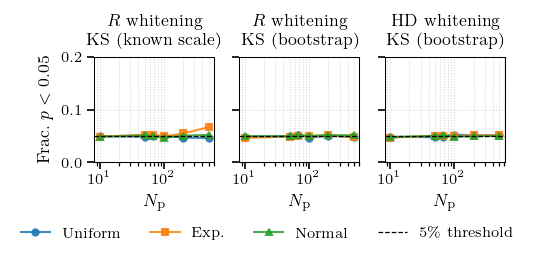

Saved plots/fig2_isotropic_ks.pdf


In [43]:
use_tex, COLUMN_W, TEXT_W = set_paper_rcparams()
threshold = 0.05

labels = ['Uniform', 'Exp.', 'Normal']
markers = ['o', 's', '^']
colors = ['tab:blue', 'tab:orange', 'tab:green']

panel_info = [
    ('$R$ whitening\nKS (known scale)', pval_R_known),
    ('$R$ whitening\nKS (bootstrap)',    pval_R_boot),
    ('HD whitening\nKS (bootstrap)',    pval_HD_boot),
]

fig, axes = plt.subplots(1, 3, figsize=(COLUMN_W, 1.8), sharey=True)

for ax, (title, data) in zip(axes, panel_info):
    for i_dist, (label, marker, color) in enumerate(zip(labels, markers, colors)):
        fracs = [np.mean(data[i_dist, i_np] < threshold)
                 for i_np in range(len(N_pulsars))]
        ax.plot(N_pulsars, fracs, '-', marker=marker, color=color,
                alpha=0.85, label=label)
    ax.axhline(threshold, color='k', linestyle='--', linewidth=0.6, alpha=1., zorder=100,
               label=r'$5\%$ threshold')
    ax.set_xscale('log')
    ax.set_ylim(0.0, 0.2)
    ax.set_xlabel(r'$N_{\mathrm{p}}$')
    ax.tick_params(axis='both', which='major', pad=2)
    ax.grid(True, which='both', ls=':', lw=0.5, alpha=0.5)
    ax.set_title(title)

axes[0].set_ylabel(r'Frac.\ $p < 0.05$' if use_tex else 'Frac. p < 0.05')

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='lower center', ncol=len(legend_labels),
           bbox_to_anchor=(0.5, 0.05), frameon=False)

plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.show()

if SAVE_PLOT:
    fig.savefig(PLOT_PATH)
    print(f'Saved {PLOT_PATH}')